In [1]:
import pandas as pd
import numpy as np
import missingno as msno
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score, classification_report, roc_curve, roc_auc_score
from sklearn.metrics import roc_curve
from sklearn.metrics import recall_score, confusion_matrix, precision_score, f1_score, accuracy_score, classification_report

In [2]:
df1 = pd.read_csv("../dataset/train.csv")
X_train = df1.drop(columns = ['Churn'])
y_train = df1['Churn'].values
df2 = pd.read_csv("../dataset/test.csv")
X_test = df2.drop(columns = ['Churn'])
y_test = df2['Churn'].values

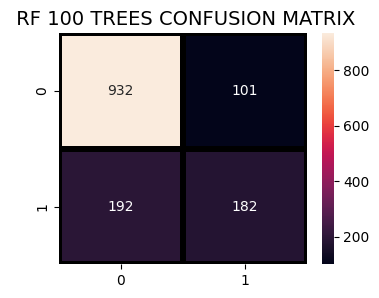

In [3]:
#simple model, number of tree = 100
rf_model = RandomForestClassifier(n_estimators=100, max_depth=None, random_state=42)
#train
rf_model.fit(X_train, y_train)
#test
y_pred_100 = rf_model.predict(X_test)
#result
plt.figure(figsize=(4,3))
sns.heatmap(confusion_matrix(y_test, y_pred_100), annot=True,fmt = "d",linecolor="k",linewidths=3)
plt.title(" RF 100 TREES CONFUSION MATRIX",fontsize=14)
plt.show()

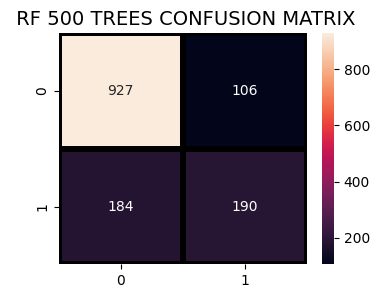

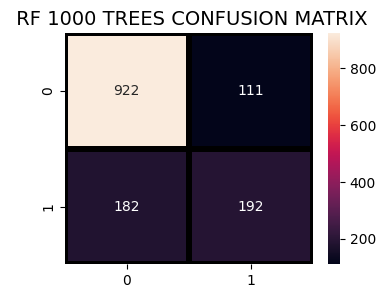

In [ ]:
#as we increase the number of tree, the model will be more balanced, better precision and recall but takes longer
#but it's alright will small data like our work
#500 trees
rf_model = RandomForestClassifier(n_estimators=500, max_depth=None, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_500 = rf_model.predict(X_test)
plt.figure(figsize=(4,3))
sns.heatmap(confusion_matrix(y_test, y_pred_500), annot=True,fmt = "d",linecolor="k",linewidths=3)
plt.title(" RF 500 TREES CONFUSION MATRIX",fontsize=14)
plt.show()

#1000 trees
rf_model = RandomForestClassifier(n_estimators=1000, max_depth=None, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_1000 = rf_model.predict(X_test)
plt.figure(figsize=(4,3))
sns.heatmap(confusion_matrix(y_test, y_pred_1000), annot=True,fmt = "d",linecolor="k",linewidths=3)
plt.title(" RF 1000 TREES CONFUSION MATRIX",fontsize=14)
plt.show()

#500 and 1000 trees give the similar effect but will take longer, so 100 is enough


Random Forest with 100 tree and max_depth=5


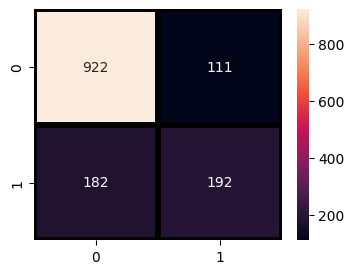


Random Forest with 100 tree and max_depth=10


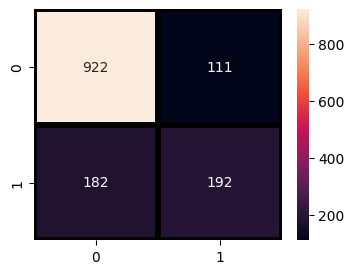


Random Forest with 100 tree and max_depth=20


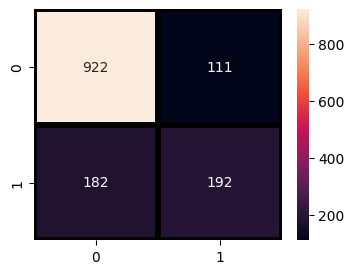

In [ ]:
#set a limit for max depth (which defaultly is None)
#if we do not limit max depth, the model is likely to overgrow and show bias, especially for skew models like Churn
for depth in [5, 10, 20]:
    rf = RandomForestClassifier(
        n_estimators=100,
        max_depth=depth,
        random_state=42,
        class_weight='balanced'
    )
    rf.fit(X_train, y_train)
    y_pred_numtree = rf.predict(X_test)
    
    print(f"\nRandom Forest with 100 tree and max_depth={depth}")
    plt.figure(figsize=(4,3))
    sns.heatmap(confusion_matrix(y_test, y_pred_1000), annot=True,fmt = "d",linecolor="k",linewidths=3)
    plt.show()

#depth = 5 or 10 are the most optimal, giving still balanced result and avoiding overfitting risk

             Feature  Importance
14          Contract    0.168591
4             tenure    0.145079
18      TotalCharges    0.135556
17    MonthlyCharges    0.130020
11       TechSupport    0.076608
8     OnlineSecurity    0.071790
7    InternetService    0.051566
16     PaymentMethod    0.044424
9       OnlineBackup    0.023886
15  PaperlessBilling    0.021651


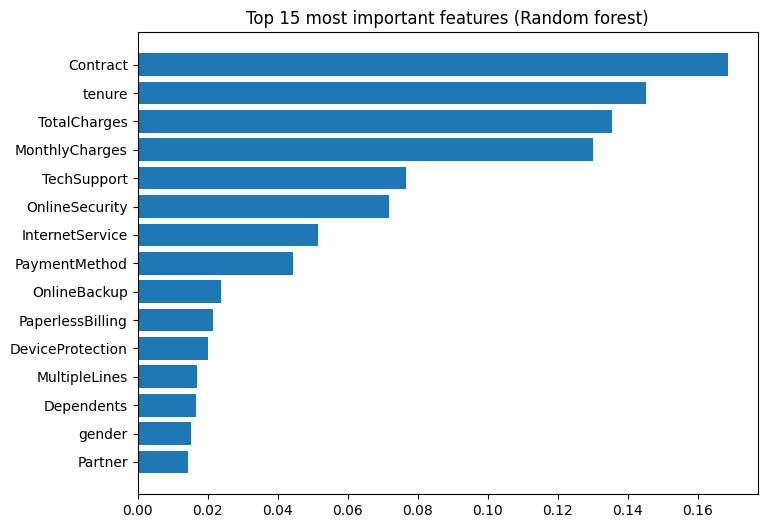

In [ ]:
#feature importance
#set up the model according to chosen optimization way above (100 tree, depth 10, class weight)
rf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, class_weight='balanced')
rf.fit(X_train, y_train)

#get ft importance
importances = rf.feature_importances_
feature_names = X_train.columns
#create new data with top 15 features only
feat_imp = pd.DataFrame({'Feature': feature_names,'Importance': importances}).sort_values(by='Importance', ascending=False)
#print out top 10 important ft
print(feat_imp.head(10))
#draw chart for top 15
plt.figure(figsize=(8,6))
plt.barh(feat_imp['Feature'][:15], feat_imp['Importance'][:15])
plt.gca().invert_yaxis()
plt.title("Top 15 most important features (Random forest)")
plt.show()

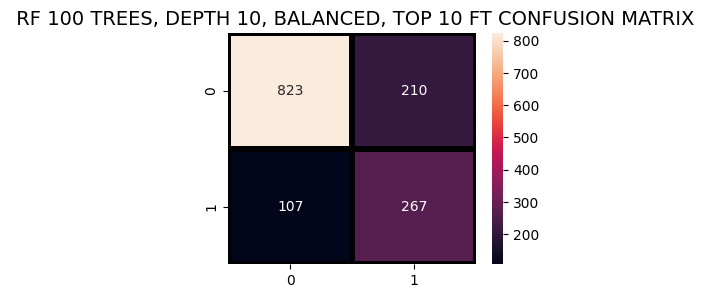

In [9]:
#train the model again with top 10 only
top_features = feat_imp['Feature'].head(10).values
X_train_top = X_train[top_features]
X_test_top = X_test[top_features]
rf_top = RandomForestClassifier(n_estimators=500, max_depth=10, random_state=42, class_weight='balanced'
)
rf_top.fit(X_train_top, y_train)

y_pred_top = rf_top.predict(X_test_top)

plt.figure(figsize=(4,3))
sns.heatmap(confusion_matrix(y_test, y_pred_top), annot=True,fmt = "d",linecolor="k",linewidths=3)
plt.title(" RF 100 TREES, DEPTH 10, BALANCED, TOP 10 FT CONFUSION MATRIX",fontsize=14)
plt.show()

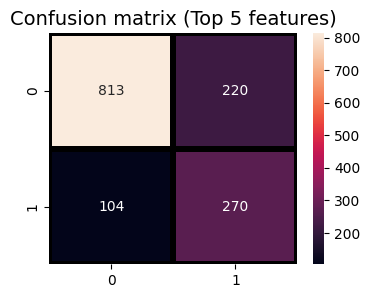

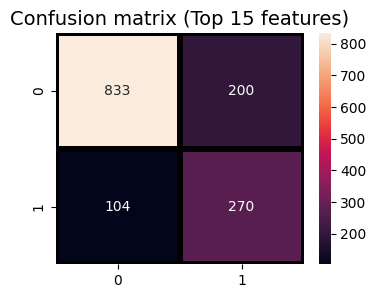

In [ ]:
top5_features = feat_imp['Feature'].head(5).values
top15_features = feat_imp['Feature'].head(15).values
#train def
def train_and_evaluate(features, label):
    X_train_sub = X_train[features]
    X_test_sub = X_test[features]
    
    rf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, class_weight='balanced')
    rf.fit(X_train_sub, y_train)
    y_pred = rf.predict(X_test_sub)
    
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(4,3))
    sns.heatmap(cm, annot=True, fmt="d", linecolor="k", linewidths=3)
    plt.title(f"Confusion matrix ({label} features)", fontsize=14)
    plt.show()

train_and_evaluate(top5_features, "Top 5")
train_and_evaluate(top15_features, "Top 15")
#top 15 features is the best model among these, however efficiency is till weaker than full features.
#could be useful if our target is simplyfing model, not prioritizing efficiency

Best parameters: {'class_weight': 'balanced', 'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 100}


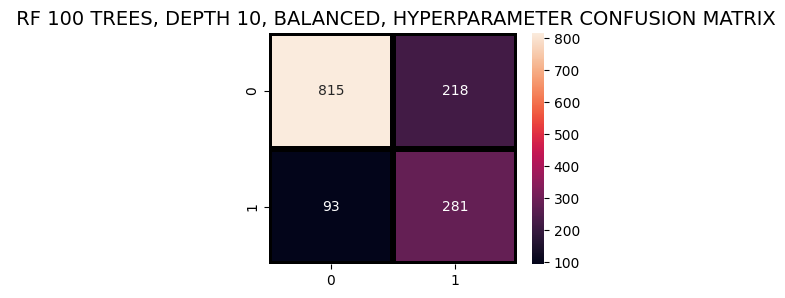

In [12]:
#hyperparameter tuning
from sklearn.model_selection import GridSearchCV

param_grid = {'n_estimators': [100], 'max_depth': [10], 'min_samples_split': [2, 5, 10], 'min_samples_leaf': [1, 2, 4], 'class_weight': ['balanced']}

rf = RandomForestClassifier(random_state=42)
grid = GridSearchCV(rf, param_grid, cv=5, scoring='f1', n_jobs=-1)
grid.fit(X_train, y_train)

print("Best parameters:", grid.best_params_)
best_rf = grid.best_estimator_

y_pred_para = best_rf.predict(X_test)

plt.figure(figsize=(4,3))
sns.heatmap(confusion_matrix(y_test, y_pred_para), annot=True,fmt = "d",linecolor="k",linewidths=3)
plt.title(" RF 100 TREES, DEPTH 10, BALANCED, HYPERPARAMETER CONFUSION MATRIX",fontsize=14)
plt.show()

In [14]:
#final summary
data = {
    "Model": [
        "Base (100 trees)",
        "500 trees",
        "100 trees + max_depth=10",
        "100 trees + max_depth=10 + top 15 features",
        "100 trees + max_depth=10 + hyperparameter tuning"
    ],
    "TN": [932, 927, 922, 833, 815],
    "FN": [101, 106, 111, 200, 218],
    "FP": [192, 184, 182, 104, 93],
    "TP": [182, 190, 192, 270, 281]
}
df_results = pd.DataFrame(data)

styled_results = (
    df_results.style
    .background_gradient(cmap="Blues")
    .set_properties(**{"text-align": "center"})
    .set_table_styles([
        {"selector": "th", "props": [
            ("border", "1px solid black"),
            ("text-align", "center"),
            ("padding", "6px")
        ]},
        {"selector": "td", "props": [
            ("border", "1px solid black"),
            ("text-align", "center"),
            ("padding", "6px")
        ]},
        {"selector": "table", "props": [
            ("border-collapse", "collapse")
        ]}
    ])
)
styled_results

,Model,TN,FN,FP,TP
0,Base (100 trees),932,101,192,182
1,500 trees,927,106,184,190
2,100 trees + max_depth=10,922,111,182,192
3,100 trees + max_depth=10 + top 15 features,833,200,104,270
4,100 trees + max_depth=10 + hyperparameter tuning,815,218,93,281


In [15]:
data = {
    "Model": [
        "Base (100 trees)",
        "500 trees",
        "100 trees + max_depth=10",
        "100 trees + max_depth=10 + top 15 features",
        "100 trees + max_depth=10 + hyperparameter tuning"
    ],
    "Accuracy": [0.79, 0.79, 0.79, 0.78, 0.78],
    "Precision": [0.83, 0.83, 0.83, 0.89, 0.90],
    "Recall": [0.90, 0.90, 0.89, 0.81, 0.80],
    "F1-score": [0.86, 0.86, 0.86, 0.85, 0.85]
}
df_results = pd.DataFrame(data)

styled_results = (
    df_results.style
    .background_gradient(cmap="Blues")
    .set_properties(**{"text-align": "center"})
    .set_table_styles([
        {"selector": "th", "props": [
            ("border", "1px solid black"),
            ("text-align", "center"),
            ("padding", "6px")
        ]},
        {"selector": "td", "props": [
            ("border", "1px solid black"),
            ("text-align", "center"),
            ("padding", "6px")
        ]},
        {"selector": "table", "props": [
            ("border-collapse", "collapse")
        ]}
    ])
)
styled_results

,Model,Accuracy,Precision,Recall,F1-score
0,Base (100 trees),0.790000,0.830000,0.900000,0.860000
1,500 trees,0.790000,0.830000,0.900000,0.860000
2,100 trees + max_depth=10,0.790000,0.830000,0.890000,0.860000
3,100 trees + max_depth=10 + top 15 features,0.780000,0.890000,0.810000,0.850000
4,100 trees + max_depth=10 + hyperparameter tuning,0.780000,0.900000,0.800000,0.850000
